# Controling Params

In [ ]:
IMG_WIDTH = 128
IMG_HEIGHT = 128

EPOCHS = 50
BATCH_SIZE = 32

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
path = r"/content/drive/Othercomputers/My Laptop (1)/Freelance Work 2024(End)/Chaity Das UK/Implementation - Individual Modeling"
os.chdir(path)

In [ ]:
import pandas as pd
df = pd.read_csv("prepared_data/demographic_features_cleaned.csv")

import numpy as np
X_all_images = np.load("prepared_data/X_images.npy")

### Preparing Data For Age

In [ ]:
# Preparing Ages Data
df_age = df[["age", "image_path"]]
df_age = df[df_age.age<80]

X_image_age_index = df_age.index
X_image_age = X_all_images[X_image_age_index]
y_age = df_age.age.values

In [ ]:
print("Size of Age Data: ", len(y_age))

Size of Age Data:  4879


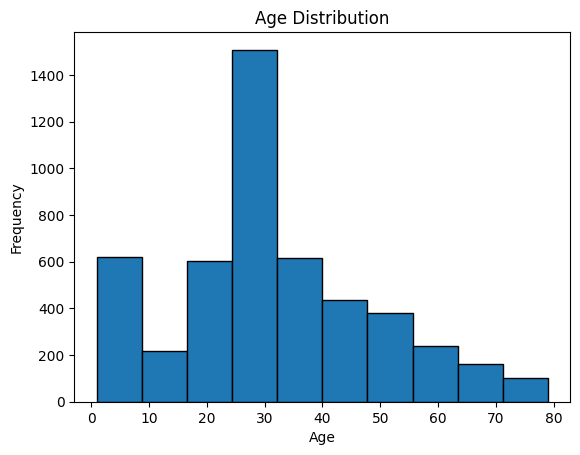

In [ ]:
import matplotlib.pyplot as plt

def generate_histogram(age_array):

  plt.hist(age_array, bins=10, edgecolor='black')
  plt.xlabel('Age')
  plt.ylabel('Frequency')
  plt.title('Age Distribution')
  plt.show()

generate_histogram(y_age)


In [ ]:
y_age_group = pd.cut(y_age, 8, labels=[1,2,3,4,5,6,7,8])
y_age_group.value_counts()

,count
1,676
2,323
3,1733
4,924
5,409
6,428
7,253
8,133


In [ ]:
from imblearn.over_sampling import SMOTE

# Flatten images and combine with age
X_flattened = X_image_age.reshape(X_image_age.shape[0], -1)
X_combined = np.column_stack((X_flattened, y_age_group))

# Apply SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_combined, y_age_group)

# Extract age and reshape images
y_age = X_resampled[:, -1]
X_image_age = X_resampled[:, :-1].reshape(-1, IMG_WIDTH, IMG_HEIGHT, 3)

print("Shape of balanced images:", X_image_age.shape)
print("Shape of balanced age labels:", y_age.shape)


Shape of balanced images: (13864, 128, 128, 3)
Shape of balanced age labels: (13864,)


In [ ]:
pd.Series(y_resampled).value_counts()

,count
3,1733
4,1733
5,1733
8,1733
7,1733
6,1733
2,1733
1,1733


### Preparing data for Gender

In [ ]:
# Preparing Ages Data
df_gender = df[["gender", "image_path"]]

X_image_gender_index = df_gender.index
X_image_gender = X_all_images[X_image_gender_index]
y_gender = df_gender.gender.map({"Male":0, "Female": 1}).values

### Preparing data for Race

In [ ]:
# Selecting columns for Race data
df_race = df[["race", "image_path"]]
df_race.race.value_counts()

,count
race,
White,1954
Indian,1097
Black,890
Asian,705
Others,354


In [ ]:
df_race.race.replace({"Asian": "Indian"}, inplace=True)
df_race.race.value_counts()

<ipython-input-14-34e1ba67bc81>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_race.race.replace({"Asian": "Indian"}, inplace=True)


,count
race,
White,1954
Indian,1802
Black,890
Others,354


In [ ]:
# Undersampling the White Race people
# Number of "Indian" records
num_indian_records = df_race[df_race['race'] == 'Indian'].shape[0]

# Sample the "White" records to match the number of "Indian" records
white_records = df_race[df_race['race'] == 'White']
white_sampled_indices = white_records.sample(n=num_indian_records, random_state=42).index

# Find the indices of the "White" records that are not in the sample
white_dropped_indices = white_records.index.difference(white_sampled_indices)

# Drop the excess "White" records from the DataFrame
df_race_filtered = df_race.drop(white_dropped_indices)

# Verify the result
print(df_race_filtered['race'].value_counts())

race
Indian    1802
White     1802
Black      890
Others     354
Name: count, dtype: int64


In [ ]:
X_images_race_index = df_race_filtered.index
X_images_race = X_all_images[X_images_race_index]
y_race = df_race_filtered.race

In [ ]:
from imblearn.over_sampling import SMOTE

# Flatten the images
X_flattened = X_images_race.reshape(X_images_race.shape[0], -1)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flattened, y_race)

# Reshape the images back to their original shape
X_images_race = X_resampled.reshape(X_resampled.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)
y_race = y_resampled

print(y_race.value_counts())

race
Indian    1802
White     1802
Others    1802
Black     1802
Name: count, dtype: int64


In [ ]:
# Encoding y_race (OnehotEncoding)
y_race = pd.get_dummies(y_race)
y_race.head()

,Black,Indian,Others,White
0,False,True,False,False
1,False,False,False,True
2,False,False,True,False
3,False,False,False,True
4,False,False,True,False


# Modeling

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

    # Plot accuracy
    axs[0].plot(history.history['accuracy'], label='Train Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_title('Model Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend(loc='lower right')

    # Plot loss
    axs[1].plot(history.history['loss'], label='Train Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_title('Model Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

### a) Gender Model

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_image_gender, y_gender, test_size=0.2, random_state=42, stratify=y_gender)
datagen.fit(X_train)

In [ ]:
# Transfer learning model
def build_transfer_learning_model(input_shape):
    base_model = tf.keras.applications.VGG16(input_shape=input_shape, include_top=False, weights='imagenet')

    # Make only the first 10 layers of the base model trainable
    for layer in base_model.layers[:10]:
        layer.trainable = True
    for layer in base_model.layers[10:]:
        layer.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
model_gender = build_transfer_learning_model(input_shape)

# Add checkpoints and train the model
checkpoint_cb = ModelCheckpoint('best_models/gender_model.keras', monitor="val_accuracy", mode="max", save_best_only=True)
early_stopping_cb = EarlyStopping(patience=5, monitor="val_accuracy", mode="max", restore_best_weights=True)

history = model_gender.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), epochs=EPOCHS, validation_data=(X_test, y_test),
                           callbacks=[checkpoint_cb, early_stopping_cb])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - accuracy: 0.5063 - loss: 0.7437 - val_accuracy: 0.5280 - val_loss: 0.6910
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.5176 - loss: 0.6991 - val_accuracy: 0.5280 - val_loss: 0.6928
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.5229 - loss: 0.6961 - val_accuracy: 0.5280 - val_loss: 0.6939
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.5478 - loss: 0.6870 - val_accuracy: 0.6160 - val_loss: 0.6584
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.5787 - loss: 0.6724 - val_accuracy: 0.6600 - val_loss: 0.6298
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.6289 - loss: 0.6465 - val_accuracy: 0.6630 - val_loss: 0.6191
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.6261 - loss: 0.6481 - val_accuracy: 0.6850 - val_loss: 0.6016
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - accuracy: 0.6483 - loss: 0.6282 - val

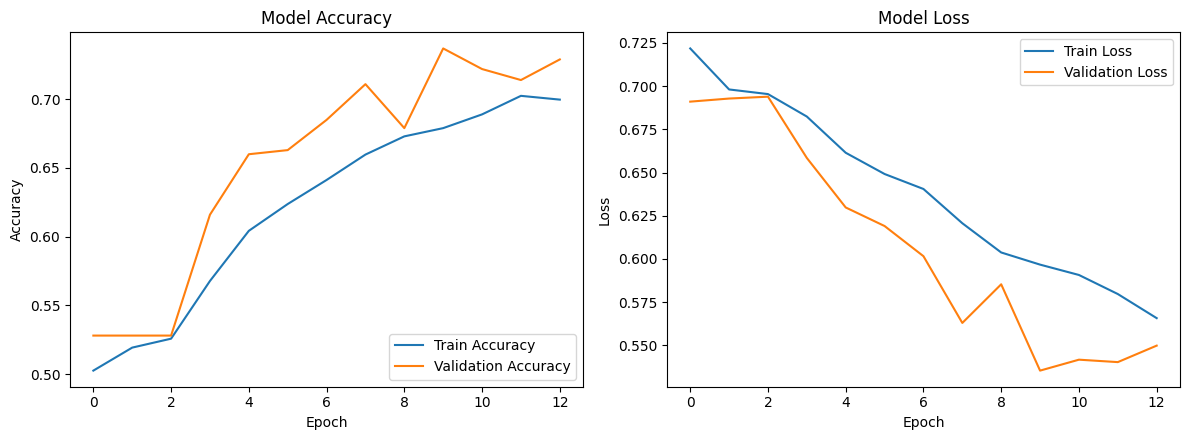

In [ ]:
plot_training_history(history)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns

In [ ]:
def evaluate_model(y_true, y_pred, y_pred_prob):
    # Calculate accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Print confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Print accuracy, precision, recall, and F1 score
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Calculate and plot ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    auc = roc_auc_score(y_true, y_pred_prob)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='best')
    plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       528
           1       0.78      0.62      0.69       472

    accuracy                           0.74      1000
   macro avg       0.75      0.73      0.73      1000
weighted avg       0.74      0.74      0.73      1000



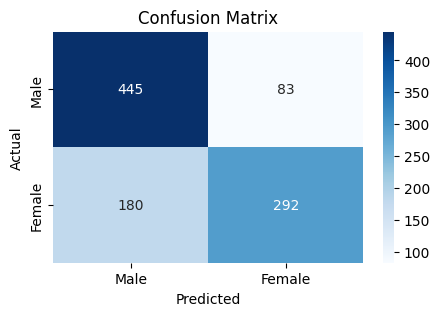

Accuracy: 0.74
Precision: 0.78
Recall: 0.62
F1 Score: 0.69


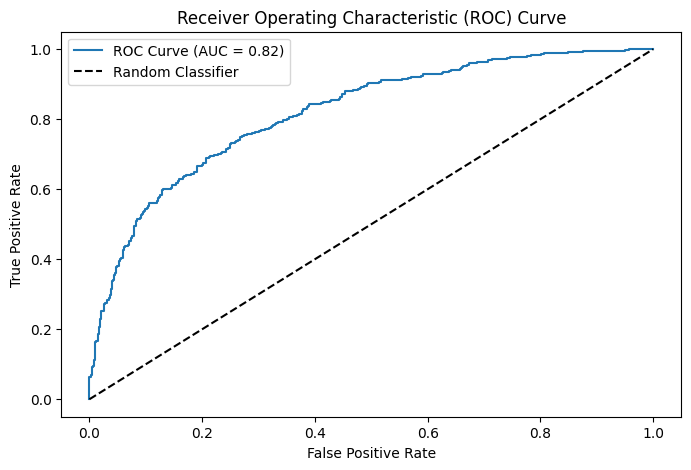

In [ ]:
# Get predictions
y_pred_prob = model_gender.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the model
evaluate_model(y_test, y_pred, y_pred_prob)

## Race Model

In [ ]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_images_race, y_race, test_size=0.2, random_state=42, stratify=y_race)
datagen.fit(X_train)

In [ ]:
import tensorflow as tf

# Transfer learning model
def build_transfer_learning_model(input_shape):
    base_model = tf.keras.applications.VGG16(input_shape=input_shape, include_top=False, weights='imagenet')

    # Make only the first 10 layers of the base model trainable
    for layer in base_model.layers[:10]:
        layer.trainable = True
    for layer in base_model.layers[10:]:
        layer.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')  # Multi classification
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
model_race = build_transfer_learning_model(input_shape)

# Add checkpoints and train the model
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('best_models/race_model.keras', monitor="val_accuracy", mode="max", save_best_only=True)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_accuracy", mode="max", restore_best_weights=True)

history = model_race.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), epochs=EPOCHS, validation_data=(X_test, y_test),
                           callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.2397 - loss: 1.4636 - val_accuracy: 0.3079 - val_loss: 1.3807
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.2794 - loss: 1.3727 - val_accuracy: 0.3613 - val_loss: 1.3030
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.3384 - loss: 1.3298 - val_accuracy: 0.3585 - val_loss: 1.3055
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.3548 - loss: 1.3227 - val_accuracy: 0.4161 - val_loss: 1.2524
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.4052 - loss: 1.2639 - val_accuracy: 0.4112 - val_loss: 1.2452
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.4234 - loss: 1.2333 - val_accuracy: 0.3883 - val_loss: 1.2514
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.4271 - loss: 1.2209 - val_accuracy: 0.4743 - val_loss: 1.1640
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.4583 - loss: 1.1847 -

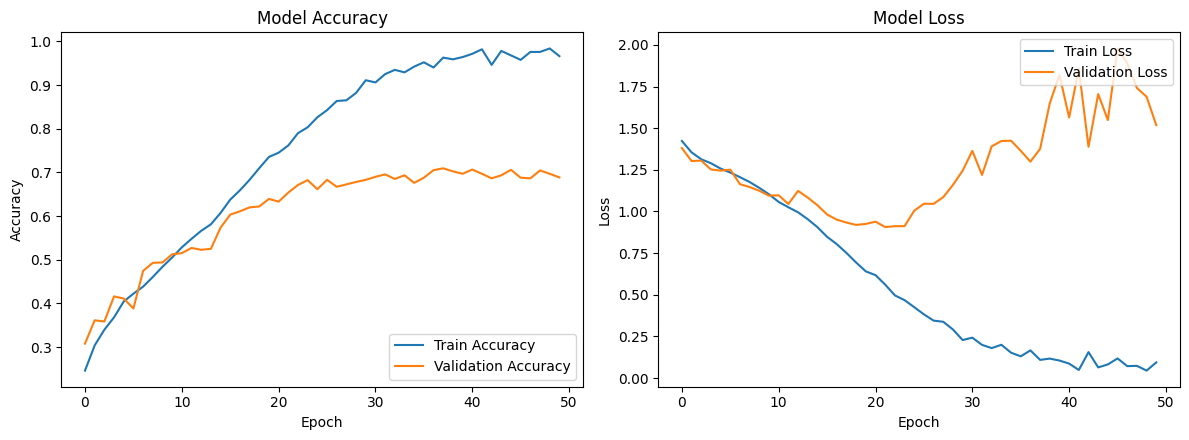

In [ ]:
plot_training_history(history)

In [ ]:
# Predict the probabilities and the class labels
y_pred_prob = model_race.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

class_names = y_test.columns

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


Classification Report:
              precision    recall  f1-score   support

       Black       0.75      0.84      0.79       360
      Indian       0.63      0.51      0.56       361
      Others       0.82      0.84      0.83       360
       White       0.62      0.64      0.63       361

    accuracy                           0.71      1442
   macro avg       0.70      0.71      0.70      1442
weighted avg       0.70      0.71      0.70      1442



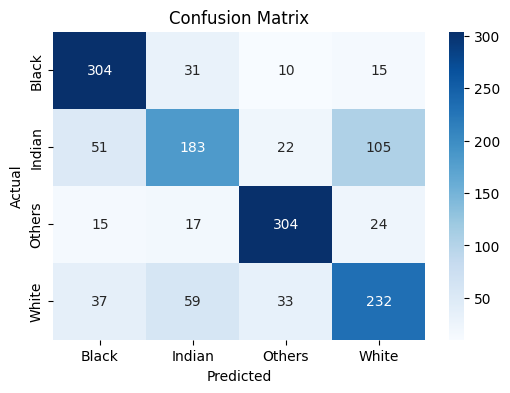

Accuracy: 0.71
Precision: 0.70
Recall: 0.71
F1 Score: 0.70


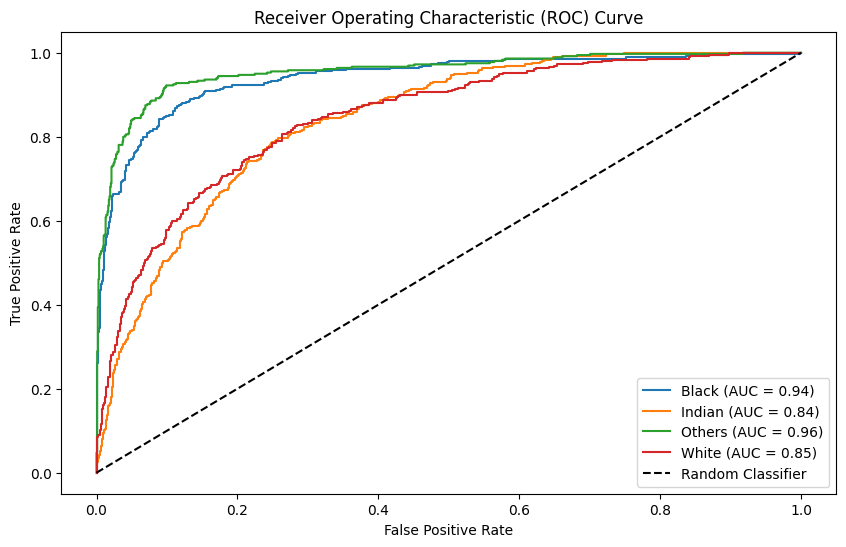

In [ ]:
from sklearn.metrics import roc_curve, auc

# Evaluate the model
def evaluate_model(y_true, y_pred, y_pred_prob, class_names):
    num_classes = len(class_names)

    # Calculate accuracy, precision, recall, and F1 score for each class
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Print confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Print accuracy, precision, recall, and F1 score
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Calculate and plot ROC curve for each class
    plt.figure(figsize=(10, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='best')
    plt.show()

# Evaluate the model
evaluate_model(y_test_labels, y_pred, y_pred_prob, class_names)


## Age Model

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_image_age, y_age, test_size=0.2, random_state=42)
datagen.fit(X_train)

In [ ]:
# Transfer learning model
def build_transfer_learning_model(input_shape):
    base_model = tf.keras.applications.VGG16(input_shape=input_shape, include_top=False, weights='imagenet')

    # Make only the first 10 layers of the base model trainable
    for layer in base_model.layers[:10]:
        layer.trainable = True
    for layer in base_model.layers[10:]:
        layer.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)  # Multi classification
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='mae',
                  metrics=['mae', "mse"])
    return model

input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
model_age = build_transfer_learning_model(input_shape)

# Add checkpoints and train the model
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('best_models/age_model.keras', monitor="val_mae", mode="min", save_best_only=True)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, monitor="val_mae", mode="min", restore_best_weights=True)

history = model_age.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), epochs=EPOCHS, validation_data=(X_test, y_test),
                           callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


347/347 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - loss: 2.1245 - mae: 2.1245 - mse: 6.6619 - val_loss: 1.9330 - val_mae: 1.9330 - val_mse: 5.3486
Epoch 2/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - loss: 1.7859 - mae: 1.7859 - mse: 4.8664 - val_loss: 1.5272 - val_mae: 1.5272 - val_mse: 3.7323
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - loss: 1.6709 - mae: 1.6709 - mse: 4.3440 - val_loss: 1.6161 - val_mae: 1.6161 - val_mse: 4.2267
Epoch 4/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - loss: 1.5828 - mae: 1.5828 - mse: 3.9931 - val_loss: 1.5128 - val_mae: 1.5128 - val_mse: 3.9844
Epoch 5/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - loss: 1.5042 - mae: 1.5042 - mse: 3.6903 - val_loss: 1.3060 - val_mae: 1.3060 - val_mse: 2.8368
Epoch 6/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - loss: 1.4791 - mae: 1.4791 - mse: 3.6075 - val_loss: 1.2526 - val_mae: 1.2526 - val_mse: 2.6204
Epoch 7/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - loss: 1.4019 - mae: 1.4019 - mse: 3.

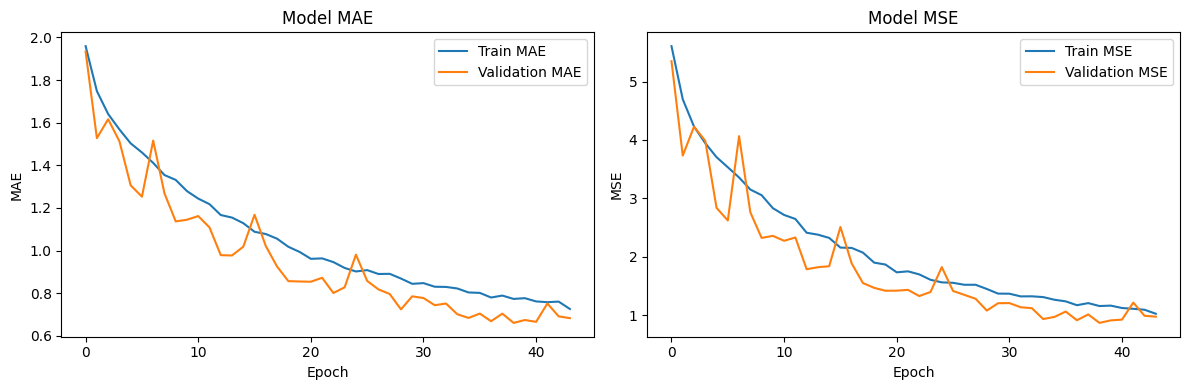

In [ ]:
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Mean Absolute Error (MAE)
    axs[0].plot(history.history['mae'], label='Train MAE')
    axs[0].plot(history.history['val_mae'], label='Validation MAE')
    axs[0].set_title('Model MAE')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('MAE')
    axs[0].legend(loc='upper right')

    # Plot Mean Squared Error (MSE)
    axs[1].plot(history.history['mse'], label='Train MSE')
    axs[1].plot(history.history['val_mse'], label='Validation MSE')
    axs[1].set_title('Model MSE')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('MSE')
    axs[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
Mean Absolute Error (MAE): 0.66
Mean Squared Error (MSE): 0.87
Root Mean Squared Error (RMSE): 0.93
R-squared (R2): 0.83


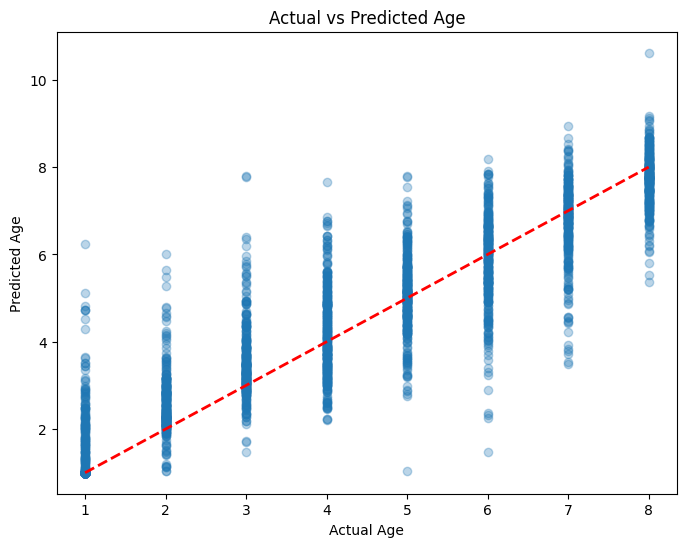

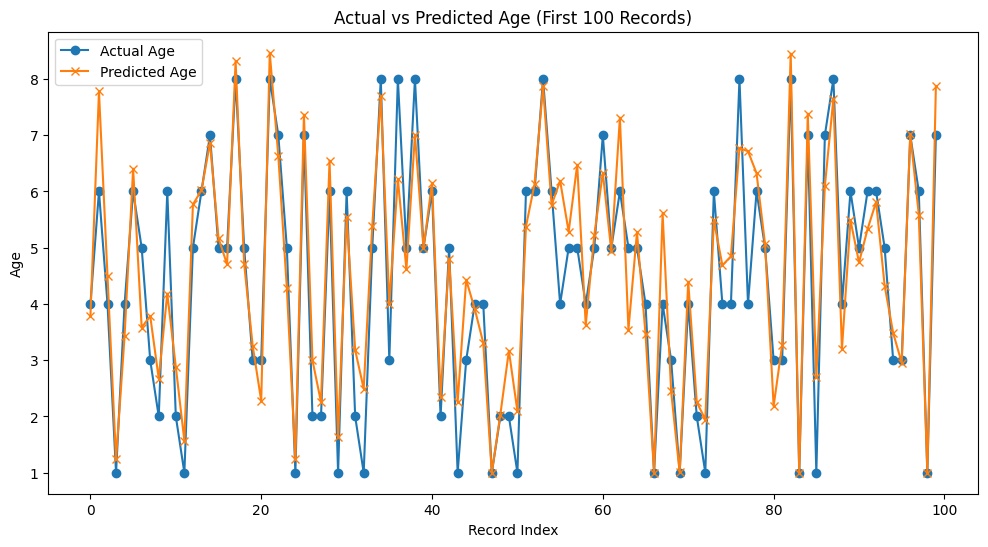

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict the age
y_pred = model_age.predict(X_test)

# Evaluate the model
def evaluate_regression_model(y_true, y_pred):
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Print evaluation metrics
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")

    # Scatter plot of true vs predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Age')
    plt.ylabel('Predicted Age')
    plt.title('Actual vs Predicted Age')
    plt.show()

    # Line plot of actual vs predicted values for the first 100 records
    plt.figure(figsize=(12, 6))
    plt.plot(y_true[:100], label='Actual Age', marker='o')
    plt.plot(y_pred[:100], label='Predicted Age', marker='x')
    plt.xlabel('Record Index')
    plt.ylabel('Age')
    plt.title('Actual vs Predicted Age (First 100 Records)')
    plt.legend()
    plt.show()

if not isinstance(y_test, np.ndarray):
    y_test = np.array(y_test)

# Evaluate the model
evaluate_regression_model(y_test, y_pred)